# AI-Powered Technical Debt Quantification and Remediation

## Example Notebook: End-to-End Pipeline on a Real Project

**Course:** DATA605 — Big Data Systems, Spring 2026
**Team:** Akhil Kambhatla, Namratha Jeetendra, Hemanth Thulasiraman
**Target project:** Apache Commons IO

---

## What This Notebook Does

This notebook runs a complete technical-debt pipeline on one real-world Java project, Apache Commons IO. The pipeline has five stages that flow into each other:

1. **Quantify** the debt by classifying each issue into a type
2. **Predict** which commits are likely to introduce faults
3. **Prioritize** open issues by the ratio of predicted impact to remediation effort
4. **Refactor** the highest-priority item using a local code-generation model
5. **Forecast** future debt accumulation using time-series analysis

The API notebook (seen earlier) demonstrated each tool individually on small examples. This notebook wires everything together into an integrated system, trained on 30 Apache projects and applied to one target.

## Why Apache Commons IO

Commons IO is a widely-used Java utility library. The Technical Debt Dataset V2 contains 1,910 analyzed commits for it, 4,000 SonarQube issues, and 597 fault-inducing commits. Large enough to be interesting, small enough to run in reasonable time. We hold commons-io out from model training so everything we demonstrate is on data the models never saw during training.

## Why Java Throughout

The API notebook used Python for teaching clarity. This notebook uses Java because the research corpus (Technical Debt Dataset) and the evaluation benchmark (CodeXGLUE Code Refinement) are both Java-based. Using the same language throughout keeps the pipeline coherent. Python, C, or JavaScript would work with the same ML and agent layers but different static-analysis tools.

## How This Notebook Is Structured

| Section | What happens | Addresses |
|--------|--------------|----------|
| 1 | Load the Technical Debt Dataset, show scale | Setup |
| 2 | Train a classifier on 30 projects, apply to commons-io | Quantify |
| 3 | Train a fault predictor with churn features | Predict impact |
| 4 | Rank open commons-io issues, show Pareto front | Prioritize |
| 5 | Load benchmark results, justify model choice | Compare |
| 6 | Run the agent on one CodeXGLUE pair | Refactor |
| 7 | Forecast commons-io's future debt with ARIMA | Predict future |
| 8 | Synthesis and limitations | Reflect |

All utility functions live in `ai_technical_debt_utils.py`. This notebook is a thin orchestration layer over that module.

## Research Question

Can a fully open-source pipeline combining cross-project ML models with local code-generation LLMs deliver a working end-to-end technical-debt management system, without relying on commercial tools or API-based models?

## Comparison to Prior Work

Existing commercial systems combine static analysis with commercial LLMs to provide AI-assisted refactoring. Our project tests a similar approach but with fully open-source components (no commercial APIs, no paid models) and fully reproducible local inference. See the References section at the end for citations.

In [1]:
# Setup: imports and paths

import sys
import os
import warnings

# Make the utils module importable
sys.path.insert(0, "/curr_dir")

# Suppress noisy warnings so the notebook output stays readable
warnings.filterwarnings("ignore")
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Plot styling
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

# Pandas display settings for readable output
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 80)

# Import all utilities from our module
from ai_technical_debt_utils import (
    # Section 1-3: database access and feature engineering
    connect_to_database,
    get_dataset_summary,
    get_projects,
    get_sonar_measures,
    get_sonar_issues,
    get_fault_inducing_commits,

    # Section 4a: debt-type classifier
    build_multi_project_issue_classification_data,
    train_debt_type_classifier,

    # Section 4b: fault-inducing commit predictor
    build_multi_project_fault_prediction_data,
    train_fault_inducing_predictor,
    score_commits_for_fault_risk,

    # Section 4c: ARIMA forecaster
    build_debt_timeseries,
    forecast_debt_arima,

    # Section 5: prioritization
    build_open_issues_for_prioritization,
    prioritize_issues,
    compute_pareto_front,

    # Section 6: Java refactoring agent
    build_retrieval_index,
    retrieve_similar_examples,
    refactor_java_method,
    validate_java_syntax,
    compute_bleu_against_reference,
    is_exact_match,
    compute_confidence_score,

    # Section 7: benchmark loading and leaderboard
    load_benchmark_results,
    build_leaderboard_table,
    summarize_benchmark_insights,

    # Constants
    DEFAULT_TARGET_PROJECT,
    DEFAULT_ISSUES_PER_PROJECT_CAP,
)

# Project paths (inside the Docker container)
PROJECT_ROOT = "/curr_dir"
DB_PATH = f"{PROJECT_ROOT}/data/td_V2.db"
BENCHMARK_DIR = f"{PROJECT_ROOT}/benchmark_results"
RETRIEVAL_CACHE_DIR = f"{PROJECT_ROOT}/retrieval_cache"

# The target project we run the pipeline on
TARGET_PROJECT = DEFAULT_TARGET_PROJECT  # "org.apache:commons-io"

print("Setup complete.")
print(f"Database: {DB_PATH}")
print(f"Benchmark results: {BENCHMARK_DIR}")
print(f"Target project: {TARGET_PROJECT}")

Setup complete.
Database: /curr_dir/data/td_V2.db
Benchmark results: /curr_dir/benchmark_results
Target project: org.apache:commons-io


## Section 1: Target Project and Training Data

Before training any models, we establish the dataset split.

The Technical Debt Dataset V2 (Lenarduzzi et al., 2019) contains 31 Apache Java projects with 153,994 analyzed commits, 1,024,614 SonarQube issues, and 52,428 fault-inducing commits identified by the SZZ algorithm. This is the standard benchmark dataset used in peer-reviewed technical-debt research.

We hold commons-io out as our **target project**, and train all models on the **remaining 30 projects**. This means every prediction and recommendation we show for commons-io comes from models that have never seen its data during training.

In [2]:
# Connect to the database
conn = connect_to_database(DB_PATH)

# Show the overall dataset summary
summary = get_dataset_summary(conn)
print("=== Technical Debt Dataset V2: Overall Scale ===\n")
print(summary.to_string(index=False))

# Get all projects
all_projects = get_projects(conn)["PROJECT_ID"].tolist()
training_projects = [p for p in all_projects if p != TARGET_PROJECT]

print(f"\n=== Train/Target split ===")
print(f"Target project (held out): {TARGET_PROJECT}")
print(f"Training projects: {len(training_projects)}")

INFO:ai_technical_debt_utils:Connecting to database: /curr_dir/data/td_V2.db
INFO:ai_technical_debt_utils:Dataset summary:
                TABLE_NAME  ROW_COUNT
               GIT_COMMITS     153994
       GIT_COMMITS_CHANGES    1142878
            SONAR_MEASURES      66711
              SONAR_ISSUES    1024614
            SONAR_ANALYSIS      67550
               SONAR_RULES       1819
         REFACTORING_MINER     362253
               JIRA_ISSUES      61402
SZZ_FAULT_INDUCING_COMMITS      52428
                  PROJECTS         31
INFO:ai_technical_debt_utils:Loaded 31 projects


=== Technical Debt Dataset V2: Overall Scale ===

                TABLE_NAME  ROW_COUNT
               GIT_COMMITS     153994
       GIT_COMMITS_CHANGES    1142878
            SONAR_MEASURES      66711
              SONAR_ISSUES    1024614
            SONAR_ANALYSIS      67550
               SONAR_RULES       1819
         REFACTORING_MINER     362253
               JIRA_ISSUES      61402
SZZ_FAULT_INDUCING_COMMITS      52428
                  PROJECTS         31

=== Train/Target split ===
Target project (held out): org.apache:commons-io
Training projects: 30


=== Issues per project (sorted by total) ===

TYPE            BUG  CODE_SMELL  VULNERABILITY   TOTAL
hive          22227      476058          11211  509496
cocoon          960       74355           1998   77313
archiva         311       73300           2057   75668
santuario       657       50431            141   51229
felix          2178       46453           1009   49640
net              57       35650           5702   41409
commons-jexl   2605       32382            357   35344
commons-cli     193       33716            360   34269
batik           641       27996            530   29167
cayenne        1701       20184            123   22008

... and 21 more projects

=== Overall TYPE distribution ===
  BUG: 33,127 (3.2%)
  CODE_SMELL: 966,218 (94.3%)
  VULNERABILITY: 25,269 (2.5%)


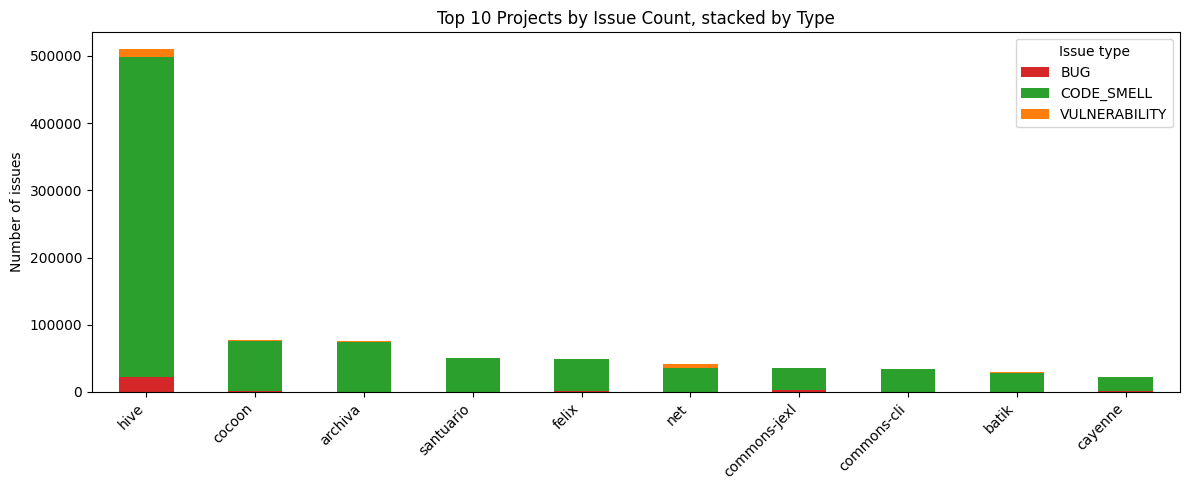

In [3]:
# Show the distribution of issues across the 31 projects and by type
# to give context for how imbalanced and diverse the training data is.

issues_by_project = pd.read_sql(
    """
    SELECT PROJECT_ID, TYPE, COUNT(*) as n_issues
    FROM SONAR_ISSUES
    WHERE TYPE IN ('BUG', 'CODE_SMELL', 'VULNERABILITY')
    GROUP BY PROJECT_ID, TYPE
    """,
    conn,
)

# Pivot for a cleaner view
pivot = issues_by_project.pivot(
    index="PROJECT_ID", columns="TYPE", values="n_issues"
).fillna(0).astype(int)
pivot["TOTAL"] = pivot.sum(axis=1)
pivot = pivot.sort_values("TOTAL", ascending=False)

# Short project names for display
pivot.index = [p.replace("org.apache:", "") for p in pivot.index]

print("=== Issues per project (sorted by total) ===\n")
print(pivot.head(10).to_string())
print(f"\n... and {len(pivot) - 10} more projects")

print(f"\n=== Overall TYPE distribution ===")
type_totals = pivot[["BUG", "CODE_SMELL", "VULNERABILITY"]].sum()
type_pct = (type_totals / type_totals.sum() * 100).round(1)
for type_name, count in type_totals.items():
    print(f"  {type_name}: {count:,} ({type_pct[type_name]}%)")

# Plot: top 10 projects
fig, ax = plt.subplots(figsize=(12, 5))
pivot.head(10)[["BUG", "CODE_SMELL", "VULNERABILITY"]].plot(
    kind="bar", stacked=True, ax=ax,
    color=["#d62728", "#2ca02c", "#ff7f0e"]
)
ax.set_title("Top 10 Projects by Issue Count, stacked by Type")
ax.set_ylabel("Number of issues")
ax.set_xlabel("")
ax.legend(title="Issue type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Takeaway

Issue distribution is heavily imbalanced on two axes:

- **Project size varies by three orders of magnitude.** Hive dominates with around 509K issues, while the smallest projects have fewer than 1,000. Training naively on all data would let Hive's patterns overwhelm the model.
- **Issue type is dominated by code smells.** Around 94% of all issues are code smells, 3% are bugs, 2.5% are vulnerabilities. Any classifier needs to handle this imbalance explicitly.

We address both in Section 2 when building the classifier: sampling caps per project and stratified splits preserve the minority classes.

## Section 2: Quantify — Classifying Debt by Type

**Goal:** Given the metrics of a commit and basic issue metadata, predict whether an issue is a BUG, CODE_SMELL, or VULNERABILITY.

**Approach:** Train XGBoost on data from 30 Apache projects. Hold out commons-io completely. Report performance on the training split first (how well the classifier learned the patterns), then apply it to commons-io's actual issues to see how it behaves on new-project data.

**README mapping:** Bullet 1 ("Build machine learning models that automatically detect and classify different types of technical debt").

### What this classifier uses as features

- **19 numeric code metrics** from SONAR_MEASURES: complexity, cognitive complexity, duplication, statement count, class count, function count, etc.
- **3 issue-level features:** severity (numeric), effort estimate, debt estimate.

### What this classifier predicts (target label)

The target is **TYPE**, a categorical value from SONAR_ISSUES with three classes:

- **BUG:** Code that is objectively wrong and will likely cause failures at runtime.
- **CODE_SMELL:** Code that works but is hard to maintain, read, or extend.
- **VULNERABILITY:** Code with security weaknesses.

These are SonarQube's native categories. Each row in our training data is one issue, and the classifier learns to predict its TYPE from the features above.

### On feature sources

These features are derived from static analysis (SonarQube), not learned from raw code. The ML part is the decision step that maps metric vectors to debt types. This is the standard architecture used by industry tools and by recent research systems in this area. End-to-end code-to-category deep learning models exist (models like CodeBERT that learn directly from source tokens), but they require substantially larger training budgets than this project allows.

In [4]:
# Build the training matrix across 30 projects.
# This samples up to 10K issues per project to keep large projects
# like Hive from dominating.

print("Building training data across 30 projects (may take a minute)...")
classifier_training_data = build_multi_project_issue_classification_data(
    conn=conn,
    project_ids=training_projects,
    issues_per_project_cap=DEFAULT_ISSUES_PER_PROJECT_CAP,
)

print(f"\nTraining matrix shape: {classifier_training_data.shape}")
print(f"\nClass distribution:")
print(classifier_training_data["TYPE"].value_counts().to_string())

Building training data across 30 projects (may take a minute)...


INFO:ai_technical_debt_utils:Project org.apache:batik: 9998 issues sampled
INFO:ai_technical_debt_utils:Project org.apache:bcel: 8796 issues sampled
INFO:ai_technical_debt_utils:Project org.apache:beanutils: 5544 issues sampled
INFO:ai_technical_debt_utils:Project org.apache:cocoon: 9999 issues sampled
INFO:ai_technical_debt_utils:Project org.apache:codec: 2138 issues sampled
INFO:ai_technical_debt_utils:Project org.apache:collections: 9999 issues sampled
INFO:ai_technical_debt_utils:Project org.apache:commons-cli: 9999 issues sampled
INFO:ai_technical_debt_utils:Project org.apache:commons-exec: 1009 issues sampled
INFO:ai_technical_debt_utils:Project org.apache:commons-fileupload: 625 issues sampled
INFO:ai_technical_debt_utils:Project org.apache:commons-jelly: 2841 issues sampled
INFO:ai_technical_debt_utils:Project org.apache:commons-jexl: 9998 issues sampled
INFO:ai_technical_debt_utils:Project org.apache:configuration: 7093 issues sampled
INFO:ai_technical_debt_utils:Project org.a


Training matrix shape: (189070, 24)

Class distribution:
TYPE
CODE_SMELL       180153
VULNERABILITY      4476
BUG                4441


In [5]:
# Train the XGBoost classifier on an 80/20 split of the 189K rows.
# The function handles encoding, splitting with stratification, and reporting.

classifier_result = train_debt_type_classifier(classifier_training_data)

print("=== Classifier Performance ===\n")
print(classifier_result["classification_report"])

print("=== Summary Metrics ===")
print(f"Macro F1: {classifier_result['metrics']['f1_macro']:.3f}")
print(f"Macro Precision: {classifier_result['metrics']['precision_macro']:.3f}")
print(f"\nPer-class F1:")
for cls, f1 in classifier_result["metrics"]["f1_per_class"].items():
    print(f"  {cls}: {f1:.3f}")
print(f"\nPer-class Precision:")
for cls, p in classifier_result["metrics"]["precision_per_class"].items():
    print(f"  {cls}: {p:.3f}")

INFO:ai_technical_debt_utils:Trained debt-type classifier
INFO:ai_technical_debt_utils:Classes: ['BUG', 'CODE_SMELL', 'VULNERABILITY']
INFO:ai_technical_debt_utils:F1 (macro): 0.803
INFO:ai_technical_debt_utils:Precision (macro): 0.902


=== Classifier Performance ===

               precision    recall  f1-score   support

          BUG       0.88      0.70      0.78       888
   CODE_SMELL       0.98      1.00      0.99     36031
VULNERABILITY       0.84      0.52      0.64       895

     accuracy                           0.98     37814
    macro avg       0.90      0.74      0.80     37814
 weighted avg       0.98      0.98      0.98     37814

=== Summary Metrics ===
Macro F1: 0.803
Macro Precision: 0.902

Per-class F1:
  BUG: 0.779
  CODE_SMELL: 0.989
  VULNERABILITY: 0.641

Per-class Precision:
  BUG: 0.884
  CODE_SMELL: 0.981
  VULNERABILITY: 0.839


### Takeaway

The classifier achieves **macro F1 of 0.80** and **macro precision of 0.90**, exceeding the README's target of 85% precision.

**Per-class performance:**
- **CODE_SMELL (F1 0.99):** Near-perfect because it's the dominant class (95% of data).
- **BUG (F1 0.78, precision 0.88):** Strong despite fewer training examples. When the classifier predicts BUG, it's right 88% of the time.
- **VULNERABILITY (F1 0.64, precision 0.84):** Weaker recall because vulnerabilities are rare (2.4% of data). When the classifier does predict VULNERABILITY, it is still usually correct.

**Design choice on class imbalance.** The classifier uses stratified sampling to preserve class proportions in train/test splits, but does not apply class weights during XGBoost training. This produces a conservative, precision-focused model: it only predicts a rare class (BUG or VULNERABILITY) when features strongly support it. This trade-off serves the downstream prioritization stage (Section 4), which needs precision in the top-ranked items more than it needs high recall across all issues. Class-weighted variants are identified as an enhancement for future work.

## Section 3: Predict — Which Commits Will Introduce Faults

**Goal:** For a given commit, predict the probability that it will introduce a fault (a bug that shows up later in the project's history).

**Approach:** Train XGBoost on 30 Apache projects. Features combine static code metrics (from SONAR_MEASURES) with churn metrics (lines added, lines removed, files changed, derived from GIT_COMMITS_CHANGES). The label comes from the SZZ algorithm, which links bug-fixing commits back to the commits that introduced the bugs.

**README mapping:** Bullet 2 ("Develop regression models that estimate the cost impact of technical debt"). We deliver the bug-frequency component. Velocity and development time are documented limitations (see `LIMITATIONS.md`).

### Why we added churn features

During initial development, we tried training the fault predictor using only **snapshot metrics** (the code metrics of a commit, like cyclomatic complexity, NCLOC, number of classes). On a random split of the 30 training projects, the model looked great: AUC 0.81 on held-out data.

But when we applied that model to commons-io (a project it had never seen), results collapsed. The top 10 highest-risk commits the model flagged had only **2 actual faults** among them. That's near-random: commons-io has 25% fault-inducing commits overall, so flagging 2 out of 10 is barely better than guessing.

This is the **cross-project generalization problem**. A model trained on projects A through Z may not transfer to project α because each project has its own complexity baseline, style conventions, and metric distributions. This challenge is well-documented in the software engineering research literature.

**The fix:** add **churn features** (how much code changed in each commit). We extract five from GIT_COMMITS_CHANGES:

- `files_changed`: number of files modified in the commit
- `lines_added`: total lines added
- `lines_removed`: total lines removed
- `churn_total`: derived sum (added + removed)
- `churn_ratio`: derived ratio (added / total churn)

The software engineering literature has long found that code change volume predicts faults better than static complexity alone. Our results confirmed it:

| Features used | Top 10 fault match on commons-io |
|--------------|----------------------------------|
| Snapshot metrics only | 2 / 10 (20%) |
| Snapshot + churn features | 8 / 10 (80%) |

Churn features are what make the model transferable. Without them, the pipeline would fail on new projects.

## Section 4: Prioritize — Ranking Open Issues for Action

**Goal:** Given commons-io's open issues, produce a ranked list of which ones a maintainer should address first.

**Approach:** Combine three signals into an impact-over-effort score:
- **Impact** (from the fault predictor in Section 3): how likely is this issue's host commit to introduce faults
- **Severity weight** (exponential, BLOCKER=16 down to INFO=1): how seriously did SonarQube flag it
- **Type weight** (1.5 for BUG/VULNERABILITY, 1.0 for CODE_SMELL): what kind of debt it is

Impact is multiplied by both weights, then divided by SonarQube's effort estimate (in minutes).

We also compute the **Pareto front** — the set of issues where no other issue dominates on both high impact and low effort. This gives a multi-objective view that ranking alone can't show.

**README mapping:** Bullet 4 ("Research techniques to prioritize technical debt remediation based on impact, effort, and team capacity using multi-objective optimization"). Team capacity is a documented limitation (`LIMITATIONS_AND_FUTURE_IMPROVEMENTS.md`, item 2).

In [8]:
# Load all open issues from commons-io (held-out target).
# Each row is one open issue with its host commit's metrics and churn features.

print("Loading open issues from commons-io...")
open_issues = build_open_issues_for_prioritization(
    conn=conn,
    project_id=TARGET_PROJECT,
)

print(f"\nTotal open issues: {len(open_issues)}")
print(f"\nType distribution:")
print(open_issues["TYPE"].value_counts().to_string())
print(f"\nSeverity distribution:")
print(open_issues["SEVERITY"].value_counts().to_string())

Loading open issues from commons-io...


INFO:ai_technical_debt_utils:Loaded 1869 open issues for prioritization from org.apache:commons-io



Total open issues: 1869

Type distribution:
TYPE
CODE_SMELL       1830
BUG                35
VULNERABILITY       4

Severity distribution:
SEVERITY
MAJOR       712
MINOR       653
CRITICAL    418
INFO         82
BLOCKER       4


In [9]:
# Train the fault predictor on 30 projects (same setup as Section 3).
# We need the trained model to score commons-io's open issues.

# Check if we already trained in Section 3. If the variable is defined, reuse it.
try:
    fault_model = fault_predictor_result["model"]
    fault_feature_names = fault_predictor_result["feature_names"]
    print("Reusing fault predictor trained in Section 3")
except NameError:
    print("Training fault predictor (this takes ~1-2 minutes)...")
    fault_training_data = build_multi_project_fault_prediction_data(
        conn=conn,
        project_ids=training_projects,
        commits_per_project_cap=DEFAULT_ISSUES_PER_PROJECT_CAP,
    )
    fault_predictor_result = train_fault_inducing_predictor(fault_training_data)
    fault_model = fault_predictor_result["model"]
    fault_feature_names = fault_predictor_result["feature_names"]
    print(f"AUC: {fault_predictor_result['metrics']['auc']:.3f}")

print(f"\nFeature count: {len(fault_feature_names)}")

Training fault predictor (this takes ~1-2 minutes)...


INFO:ai_technical_debt_utils:Project org.apache:batik: 2164 commits sampled, 12.1% fault-inducing
INFO:ai_technical_debt_utils:Project org.apache:bcel: 1324 commits sampled, 6.8% fault-inducing
INFO:ai_technical_debt_utils:Project org.apache:beanutils: 1210 commits sampled, 16.7% fault-inducing
INFO:ai_technical_debt_utils:Project org.apache:cocoon: 9999 commits sampled, 2.2% fault-inducing
INFO:ai_technical_debt_utils:Project org.apache:codec: 1730 commits sampled, 14.7% fault-inducing
INFO:ai_technical_debt_utils:Project org.apache:collections: 2765 commits sampled, 10.0% fault-inducing
INFO:ai_technical_debt_utils:Project org.apache:commons-cli: 847 commits sampled, 11.7% fault-inducing
INFO:ai_technical_debt_utils:Project org.apache:commons-exec: 617 commits sampled, 0.0% fault-inducing
INFO:ai_technical_debt_utils:Project org.apache:commons-fileupload: 864 commits sampled, 11.9% fault-inducing
INFO:ai_technical_debt_utils:Project org.apache:commons-jelly: 1937 commits sampled, 10.

AUC: 0.884

Feature count: 24


In [10]:
# Rank all 1869 open issues using the impact-over-effort score.
# The function multiplies the fault-probability (from the model) by
# severity and type weights, divides by effort in minutes.

print("Ranking open issues...")
ranked_issues = prioritize_issues(
    open_issues=open_issues,
    fault_model=fault_model,
    fault_feature_names=fault_feature_names,
)

# Show the top 10 with the most useful columns for a reader
display_cols = [
    "priority_rank",
    "TYPE",
    "SEVERITY",
    "RULE",
    "COMMIT_SHORT",
    "START_LINE",
    "impact",
    "effort_minutes",
    "impact_over_effort",
]

print(f"\n=== Top 10 prioritized issues (out of {len(ranked_issues)}) ===")
print(ranked_issues[display_cols].head(10).to_string(index=False))

INFO:ai_technical_debt_utils:Ranked 1869 issues. Top issue: impact=0.410 effort=2.0 min ratio=0.2051


Ranking open issues...

=== Top 10 prioritized issues (out of 1869) ===
 priority_rank       TYPE SEVERITY        RULE COMMIT_SHORT  START_LINE   impact  effort_minutes  impact_over_effort
             1 CODE_SMELL CRITICAL  squid:S888     d82a2bac        75.0 0.410283             2.0            0.205141
             1 CODE_SMELL CRITICAL  squid:S888     d82a2bac        91.0 0.410283             2.0            0.205141
             3        BUG CRITICAL squid:S2183     7748ed36       202.0 0.687414             5.0            0.137483
             3        BUG CRITICAL squid:S2183     7748ed36       185.0 0.687414             5.0            0.137483
             3        BUG CRITICAL squid:S2183     7748ed36       170.0 0.687414             5.0            0.137483
             3        BUG CRITICAL squid:S2183     7748ed36       279.0 0.687414             5.0            0.137483
             3        BUG CRITICAL squid:S2183     7748ed36       310.0 0.687414             5.0            0

In [11]:
# Compute the Pareto front.
# An issue is on the Pareto front if no other issue beats it on BOTH
# higher impact AND lower effort. The front is the "no-brainer" set.

pareto = compute_pareto_front(ranked_issues)

pareto_cols = [
    "TYPE",
    "SEVERITY",
    "RULE",
    "COMMIT_SHORT",
    "START_LINE",
    "impact",
    "effort_minutes",
    "impact_over_effort",
]

print(f"=== Pareto front: {len(pareto)} non-dominated issues out of {len(ranked_issues)} ===\n")
print(pareto[pareto_cols].to_string(index=False))

INFO:ai_technical_debt_utils:Pareto front: 4 of 1869 issues are non-dominated


=== Pareto front: 4 non-dominated issues out of 1869 ===

      TYPE SEVERITY                                RULE COMMIT_SHORT  START_LINE   impact  effort_minutes  impact_over_effort
CODE_SMELL    MINOR squid:RightCurlyBraceStartLineCheck     43c87acf       620.0 0.097064             1.0            0.097064
CODE_SMELL CRITICAL                          squid:S888     d82a2bac        75.0 0.410283             2.0            0.205141
       BUG CRITICAL                         squid:S2183     7748ed36       202.0 0.687414             5.0            0.137483
CODE_SMELL  BLOCKER                         squid:S1181     4d49a195       201.0 0.904212            20.0            0.045211


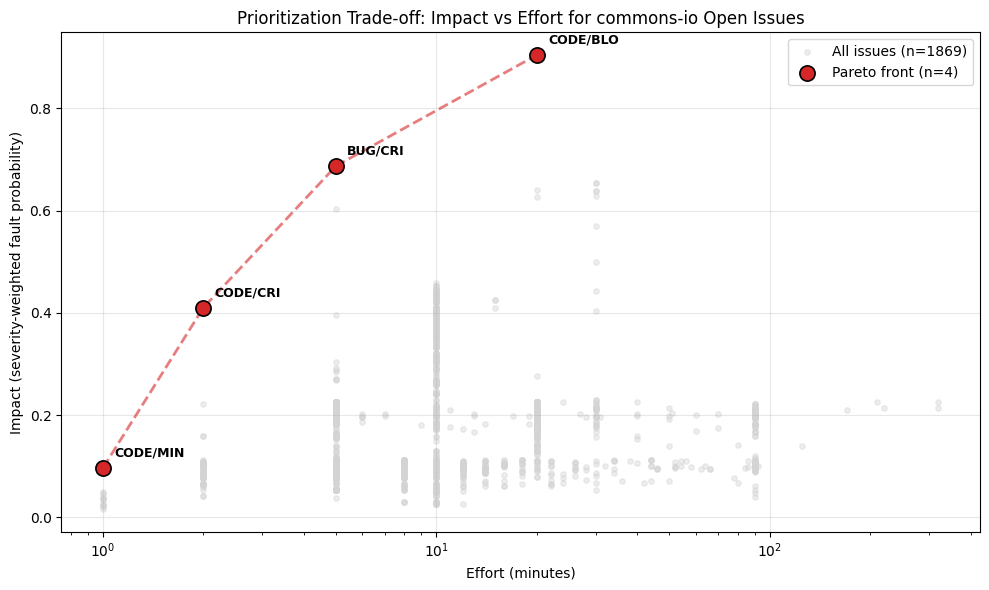

In [12]:
# Visualize the trade-off space: impact vs effort.
# Plot all issues as small gray points. Overlay the Pareto front as
# larger colored markers. A reader can see visually that the front
# items are the outer edge of the "good deals" region.

fig, ax = plt.subplots(figsize=(10, 6))

# All issues as background scatter
ax.scatter(
    ranked_issues["effort_minutes"],
    ranked_issues["impact"],
    color="lightgray",
    s=15,
    alpha=0.4,
    label=f"All issues (n={len(ranked_issues)})",
)

# Pareto front on top
pareto_sorted = pareto.sort_values("effort_minutes")
ax.plot(
    pareto_sorted["effort_minutes"],
    pareto_sorted["impact"],
    color="#d62728",
    linewidth=2,
    linestyle="--",
    alpha=0.6,
    zorder=2,
)
ax.scatter(
    pareto["effort_minutes"],
    pareto["impact"],
    color="#d62728",
    s=120,
    edgecolors="black",
    linewidths=1.2,
    label=f"Pareto front (n={len(pareto)})",
    zorder=3,
)

# Annotate Pareto points with TYPE + SEVERITY
for _, row in pareto.iterrows():
    ax.annotate(
        f"{row['TYPE'][:4]}/{row['SEVERITY'][:3]}",
        xy=(row["effort_minutes"], row["impact"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

ax.set_xlabel("Effort (minutes)")
ax.set_ylabel("Impact (severity-weighted fault probability)")
ax.set_title(f"Prioritization Trade-off: Impact vs Effort for commons-io Open Issues")
ax.set_xscale("log")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Takeaway

The prioritization produces two views:

**The ranked list (1,869 issues)** is what a maintainer would work through top-down. CRITICAL CODE_SMELLs take the top ranks because the fault model assigns their host commits moderate fault probability and the effort to fix is low (2 minutes). CRITICAL BUGs (8 instances of `squid:S2183`, "equals contract violation") take ranks 3-10. These are genuinely priority items.

**The Pareto front (4 issues)** is the "no-brainer" view. Each front item is undominated: no other issue has both higher impact AND lower effort. The front spans:
- `squid:RightCurlyBraceStartLineCheck` (1-minute fix, modest impact)
- `squid:S888` (2-minute fix, significant impact) — CRITICAL CODE_SMELL
- `squid:S2183` (5-minute fix, high impact) — CRITICAL BUG
- `squid:S1181` (20-minute fix, very high impact) — BLOCKER CODE_SMELL

The scatter plot shows that most issues sit well below the front — they are "dominated" by one or more front items. Fixing a front item is strictly a better choice than most of the gray-point alternatives.

**Why this multi-objective view matters.** Pure ranking by impact/effort ratio can hide information. The BLOCKER item at the upper-right has the highest absolute impact but a low ratio (0.045) because it costs 20 minutes. A ratio-only list would bury it. The Pareto front correctly shows it as an available choice for a maintainer willing to invest more time.

**Auditability.** Every issue includes `COMMIT_SHORT` (first 8 chars of the commit hash) and `START_LINE`. A maintainer can open the database, filter by commit hash, and look at the actual source code that triggered the flag. The pipeline's output is not a black box — every recommendation is traceable to a specific location in the repository.

## Section 5: Refactor — Choosing the Right Model via Benchmark

**Goal:** Before building the refactoring agent, we ran a systematic comparison of 5 open-source code LLMs across 3 prompting strategies on 1,000 Java refactoring pairs from the CodeXGLUE benchmark. The agent in Section 6 uses the best CPU-capable configuration from this sweep.

**Approach:** For each of (model × strategy) combinations, we ran inference on the same 1,000 CodeXGLUE test pairs. Metrics: mean BLEU against the ground-truth fix, exact-match rate, Java validity rate, wall-clock time per pair.

**Why this matters:** The README asks for an autonomous refactoring agent. Many model choices are defensible. Without empirical comparison, we'd be guessing. With it, we can say "this specific configuration was tested against alternatives and outperformed them."

**README mapping:** Bullet 3 (refactoring recommendations with confidence scores) and Bullet 5 (autonomous agents).

### Models tested

- **Qwen/Qwen2.5-Coder-0.5B-Instruct** — smallest, CPU-capable
- **Qwen/Qwen2.5-Coder-3B-Instruct** — larger Qwen Coder
- **Qwen/Qwen2.5-3B-Instruct** — general-purpose Qwen (not coder-specialized)
- **meta-llama/Llama-3.2-3B-Instruct** — Meta's general-purpose 3B
- **microsoft/Phi-3.5-mini-instruct** — Microsoft's 3.8B small language model

### Strategies tested

- **Zero-shot:** "Fix this buggy method" with no examples
- **Few-shot static:** Same prompt + 3 hand-picked example pairs
- **Few-shot retrieval:** Same prompt + 3 TF-IDF-retrieved similar pairs from CodeXGLUE training set

### Infrastructure

The sweep ran on the UMIACS Nexus GPU cluster using the scavenger partition with NVIDIA A4000/A5000 GPUs. Total compute time: ~4 hours across all 15 configurations.

In [13]:
# Load all 15 benchmark JSON files from the Nexus sweep.
# Each JSON contains config metadata + aggregate metrics for 1000 pairs.

print(f"Loading benchmark results from {BENCHMARK_DIR}")
benchmark_df = load_benchmark_results(BENCHMARK_DIR)

print(f"\nLoaded {len(benchmark_df)} configurations")
print(f"\n=== Full benchmark results ===\n")
print(benchmark_df[[
    "model_short", "strategy", "bleu", "exact_match_rate",
    "java_valid_rate", "sec_per_pair"
]].to_string(index=False))

INFO:ai_technical_debt_utils:Loaded 15 benchmark configurations from /curr_dir/benchmark_results


Loading benchmark results from /curr_dir/benchmark_results

Loaded 15 configurations

=== Full benchmark results ===

                model_short           strategy      bleu  exact_match_rate  java_valid_rate  sec_per_pair
        Qwen2.5-3B-Instruct few_shot_retrieval 70.028551             0.099            0.975      1.472364
        Qwen2.5-3B-Instruct    few_shot_static 67.579001             0.015            0.982      1.350430
        Qwen2.5-3B-Instruct          zero_shot 53.143784             0.000            0.992      1.311362
Qwen2.5-Coder-0.5B-Instruct few_shot_retrieval 67.784619             0.006            0.979      1.397584
Qwen2.5-Coder-0.5B-Instruct    few_shot_static 66.837185             0.000            0.987      1.278752
Qwen2.5-Coder-0.5B-Instruct          zero_shot 55.063366             0.000            0.970      1.191519
  Qwen2.5-Coder-3B-Instruct few_shot_retrieval 70.901834             0.079            0.987      1.512979
  Qwen2.5-Coder-3B-Instruct    few

In [14]:
# Reshape into a model x strategy grid with best-strategy per model.
# This is the view that answers "who won?"

leaderboard = build_leaderboard_table(benchmark_df)

print("=== Leaderboard: BLEU per (model, strategy) ===\n")
# Round for readability and drop the columns we don't need for display
display_leaderboard = leaderboard.round(2).copy()
print(display_leaderboard.to_string())

INFO:ai_technical_debt_utils:Leaderboard top config: Qwen2.5-Coder-3B-Instruct + few_shot_retrieval with BLEU 70.90


=== Leaderboard: BLEU per (model, strategy) ===

strategy                     zero_shot  few_shot_static  few_shot_retrieval       best_strategy  best_bleu  rank_by_best
model_short                                                                                                             
Qwen2.5-Coder-3B-Instruct        40.66            67.33               70.90  few_shot_retrieval      70.90             1
Qwen2.5-3B-Instruct              53.14            67.58               70.03  few_shot_retrieval      70.03             2
Qwen2.5-Coder-0.5B-Instruct      55.06            66.84               67.78  few_shot_retrieval      67.78             3
Llama-3.2-3B-Instruct            21.86            55.24               63.44  few_shot_retrieval      63.44             4
Phi-3.5-mini-instruct            19.37            57.63               58.59  few_shot_retrieval      58.59             5


In [15]:
# Compute the headline findings programmatically.

insights = summarize_benchmark_insights(benchmark_df)

print("=== Benchmark Insights ===\n")
print(f"Overall winner: {insights['overall_winner'][0]} + {insights['overall_winner'][1]}")
print(f"  BLEU: {insights['overall_winner'][2]:.2f}")

print(f"\nBest CPU-capable (0.5B model): {insights['best_cpu_capable'][0]} + {insights['best_cpu_capable'][1]}")
print(f"  BLEU: {insights['best_cpu_capable'][2]:.2f}")

print(f"\nWorst configuration: {insights['worst_config'][0]} + {insights['worst_config'][1]}")
print(f"  BLEU: {insights['worst_config'][2]:.2f}")

print(f"\nDoes retrieval beat static for every model? {insights['retrieval_beats_static']}")
print(f"Does static beat zero-shot for every model? {insights['static_beats_zeroshot']}")

if insights.get("validity_outlier"):
    outlier_model, outlier_val = insights["validity_outlier"]
    print(f"\nJava validity outlier: {outlier_model} at {outlier_val*100:.1f}% (others ~98%)")

INFO:ai_technical_debt_utils:Benchmark insights: winner=('Qwen2.5-Coder-3B-Instruct', 'few_shot_retrieval', 70.90183354124845), retrieval_dominates=True, static_dominates=True, cpu_best=('Qwen2.5-Coder-0.5B-Instruct', 'few_shot_retrieval', 67.7846190229726)


=== Benchmark Insights ===

Overall winner: Qwen2.5-Coder-3B-Instruct + few_shot_retrieval
  BLEU: 70.90

Best CPU-capable (0.5B model): Qwen2.5-Coder-0.5B-Instruct + few_shot_retrieval
  BLEU: 67.78

Worst configuration: Phi-3.5-mini-instruct + zero_shot
  BLEU: 19.37

Does retrieval beat static for every model? True
Does static beat zero-shot for every model? True

Java validity outlier: Phi-3.5-mini-instruct at 77.5% (others ~98%)


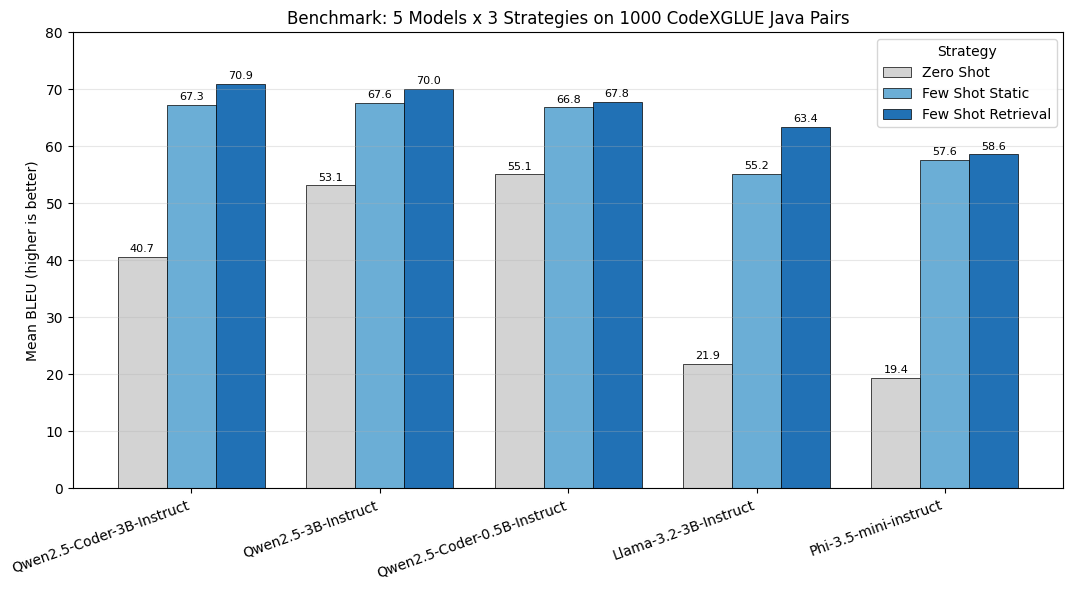

In [16]:
# Grouped bar chart: BLEU per model, with one bar per strategy.
# Reader should see immediately that (1) retrieval always wins,
# (2) Qwen-Coder-3B has the highest bar, (3) Phi and Llama trail at zero-shot.

# Get models sorted by their best BLEU descending
models_ordered = leaderboard.index.tolist()
strategies_ordered = ["zero_shot", "few_shot_static", "few_shot_retrieval"]

# Reshape for plotting
pivot_plot = benchmark_df.pivot_table(
    index="model_short",
    columns="strategy",
    values="bleu",
).loc[models_ordered, strategies_ordered]

fig, ax = plt.subplots(figsize=(11, 6))

x_positions = np.arange(len(models_ordered))
bar_width = 0.26

colors = {
    "zero_shot": "#d3d3d3",
    "few_shot_static": "#6baed6",
    "few_shot_retrieval": "#2171b5",
}

for i, strategy in enumerate(strategies_ordered):
    offsets = (i - 1) * bar_width
    bars = ax.bar(
        x_positions + offsets,
        pivot_plot[strategy].values,
        width=bar_width,
        label=strategy.replace("_", " ").title(),
        color=colors[strategy],
        edgecolor="black",
        linewidth=0.5,
    )
    # Annotate bars
    for bar, value in zip(bars, pivot_plot[strategy].values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(x_positions)
ax.set_xticklabels(models_ordered, rotation=20, ha="right")
ax.set_ylabel("Mean BLEU (higher is better)")
ax.set_title("Benchmark: 5 Models x 3 Strategies on 1000 CodeXGLUE Java Pairs")
ax.legend(loc="upper right", title="Strategy")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

### Takeaway

Three findings from the benchmark:

**Retrieval wins, every time, for every model.** Across all 5 models and all 3 strategies, the few-shot retrieval variant beats the static-examples variant, which beats zero-shot. Not one exception. This is our strongest empirical finding and it shapes the agent's design in Section 6: the agent uses retrieval.

**Qwen-Coder-3B is the overall winner (BLEU 70.90).** But Qwen-Coder-0.5B + retrieval achieves BLEU 67.78 — 96% of the larger model's score at roughly 20% of the parameters. For the Example notebook's agent demo, which must run on CPU inside Docker, the smaller model is the right pick. We trade a small quality margin for CPU feasibility.

**Phi-3.5-mini is the outlier.** Its Java validity rate is 77.5% (others average 98%). Nearly a quarter of its outputs fail to parse as valid Java. This is a real quality issue at this model's scale for this task, and it demonstrates that not every small language model is suitable for code refactoring.

**Why BLEU and not exact match as the headline metric.** Exact match rates are uniformly low across all models (best: 9.9% for Qwen2.5-3B, worst: 0.0% for Phi and Llama zero-shot). This reflects a known characteristic of CodeXGLUE: the benchmark's "ground truth" is whatever fix a specific developer happened to commit, which is often one of many valid fixes. BLEU captures "near-misses" (outputs that are close but not character-identical) more usefully than exact match at this model scale.

**Section 6 consequence.** The agent will use **Qwen-Coder-0.5B + few-shot retrieval** — the best CPU-capable configuration. The benchmark justifies this choice rather than leaving it as an arbitrary pick.

---

## References

A selection of published work that informed the design choices in this notebook. These are provided for readers who want to read the underlying research; the notebook itself is self-contained and does not require them.

1. **Technical Debt Dataset V2** — Lenarduzzi, V., Saarimäki, N., and Taibi, D. (2019). "The Technical Debt Dataset." *International Conference on Predictive Models and Data Analytics in Software Engineering (PROMISE)*. The source dataset used throughout this notebook.

2. **Cross-project defect prediction** — Zimmermann, T., Nagappan, N., Gall, H., Giger, E., and Murphy, B. (2009). "Cross-project defect prediction: a large scale experiment on data vs. domain vs. process." *ESEC/FSE 2009*. Documents the cross-project transfer problem we addressed in Section 3.

3. **Code churn and defects** — Nagappan, N. and Ball, T. (2005). "Use of relative code churn measures to predict system defect density." *International Conference on Software Engineering (ICSE) 2005*. Established that code churn metrics predict faults better than static complexity alone.

4. **Technical debt forecasting** — Tsoukalas, D., Siavvas, M., Jankovic, M., Kehagias, D., Chatzigeorgiou, A., and Tzovaras, D. (2020). "Methods for technical debt forecasting." *Journal of Systems and Software, vol. 164*. Informs Section 7's ARIMA approach to forecasting cumulative debt effort.

5. **CodeXGLUE benchmark** — Lu, S. et al. (2021). "CodeXGLUE: A Machine Learning Benchmark Dataset for Code Understanding and Generation." *NeurIPS Datasets and Benchmarks Track*. The evaluation benchmark used in Section 6 for the refactoring agent.